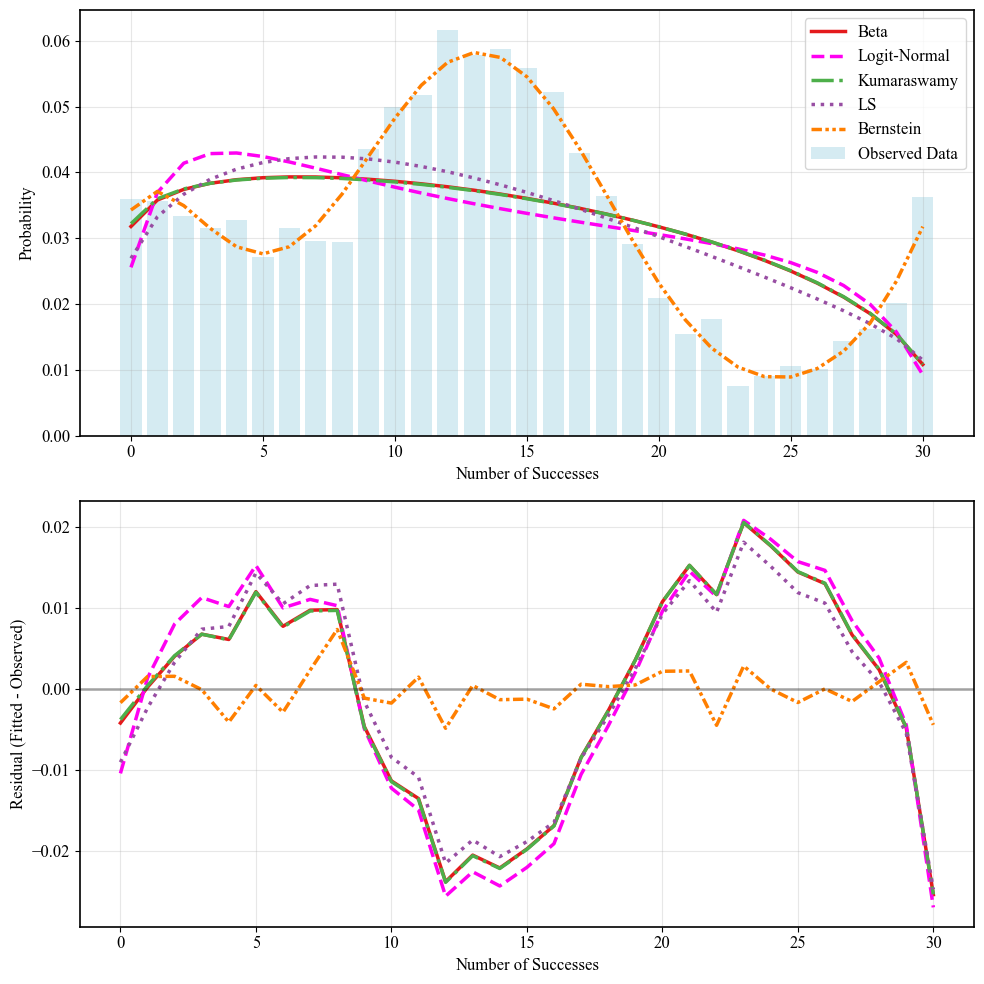

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
import seaborn as sns
from scipy.stats import binom, beta, norm
from scipy.special import expit, logit
import matplotlib.gridspec as gridspec

# 设置学术论文风格
def set_academic_style():
    """设置学术论文风格的绘图参数"""
    plt.style.use('default')
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman']
    rcParams['mathtext.fontset'] = 'stix'
    rcParams['font.size'] = 12
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 16
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    rcParams['figure.figsize'] = (10, 6)
    rcParams['figure.dpi'] = 100
    rcParams['savefig.dpi'] = 300
    rcParams['axes.linewidth'] = 1.2
    rcParams['lines.linewidth'] = 2
    rcParams['grid.linewidth'] = 0.8
    rcParams['grid.alpha'] = 0.25

# 设置样式
set_academic_style()

# 读取数据
sample_data = pd.read_csv(r'C:\Users\user\Desktop\Accurate prior of binomial distribution with Bernstein polynomial and its Bayesian inference\sample.csv')
x = sample_data['x'].values
n_trials = 30  # 二项分布试验次数
sample_size = 5000

# 2. 模型拟合结果
models = ['Beta', 'Logit-Normal', 'Kumaraswamy', 'LS', 'Bernstein']
# 模型参数 (这里只是示例，请替换为您的实际参数)
model_params = {
    'Beta': (1.120194, 1.420463),
    'Logit-Normal': (-0.3493287, 1.4886505),
    'Kumaraswamy': (1.107391, 1.420263),
    'LS': (0.4469845, 1.2134600),
    'Bernstein': np.array([4.397067e-02, 1.399036e-01, 3.331913e-02, 6.291738e-04, 1.113746e-04, 9.623777e-04, 
                           4.748693e-02, 4.794812e-01, 1.342065e-01, 1.551046e-03, 8.876687e-06, 6.489614e-07, 
                           4.562082e-06, 8.767626e-04, 2.813403e-02, 1.555434e-03, 8.779766e-02])  # K=16的Bernstein权重
}

# 定义各种先验分布的概率密度函数
def beta_prior(p, a, b):
    return beta.pdf(p, a, b)

def logit_normal_prior(p, mu, sigma):
    with np.errstate(divide='ignore', invalid='ignore'):
        mask = (p > 0) & (p < 1)
        result = np.zeros_like(p)
        result[mask] = norm.pdf(logit(p[mask]), mu, sigma) / (p[mask] * (1 - p[mask]))
        return result

def kumaraswamy_prior(p, a, b):
    return a * b * (p ** (a - 1)) * ((1 - p ** a) ** (b - 1))

def ls_prior(p, a, b):
    return b * np.exp(-a) * (p * (1 - p))**(b - 1) / (p**b + (1-p)**b * np.exp(-a))**2

def bernstein_prior(p, weights):
    K = len(weights) - 1
    result = np.zeros_like(p)
    for k in range(K + 1):
        result += weights[k] * beta.pdf(p, k + 1, K - k + 1)
    return result

# 计算二项分布的概率质量函数（考虑先验）
def binomial_with_prior_pmf(k, n, prior_func, prior_params):
    """计算考虑先验的二项分布概率质量函数"""
    # 数值积分计算边缘分布
    p_values = np.linspace(0.001, 0.999, 1000)
    prior_probs = prior_func(p_values, *prior_params)
    
    # 归一化先验概率
    prior_probs /= np.trapz(prior_probs, p_values)
    
    # 计算每个k值的概率
    pmf = np.zeros_like(k, dtype=float)
    for i, k_val in enumerate(k):
        # 二项分布概率
        binom_probs = binom.pmf(k_val, n, p_values)
        # 边缘概率
        pmf[i] = np.trapz(binom_probs * prior_probs, p_values)
    
    return pmf

# 1. 拟合优度对比图
def plot_fit_comparison():
    """绘制拟合优度对比图"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    
    # 计算观测数据的直方图
    k_values = np.arange(0, n_trials + 1)
    observed_freq, _ = np.histogram(sample_data, bins=np.arange(-0.5, n_trials + 1.5))
    observed_prob = observed_freq / sample_size
    
    # 绘制观测数据
    ax1.bar(k_values, observed_prob, alpha=0.5, color="lightblue", label='Observed Data')
    
    # 定义颜色和线型
    colors = ['#E41A1C', "#FF00F2", '#4DAF4A', '#984EA3', '#FF7F00']
    linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1, 1, 1))]
    
    # 绘制各模型的拟合曲线
    for i, model in enumerate(models):
        # 计算模型预测的概率
        if model == 'Bernstein':
            model_pmf = binomial_with_prior_pmf(k_values, n_trials, bernstein_prior, [model_params[model]])
        elif model == 'Beta':
            model_pmf = binomial_with_prior_pmf(k_values, n_trials, beta_prior, model_params[model])
        elif model == 'Logit-Normal':
            model_pmf = binomial_with_prior_pmf(k_values, n_trials, logit_normal_prior, model_params[model])
        elif model == 'Kumaraswamy':
            model_pmf = binomial_with_prior_pmf(k_values, n_trials, kumaraswamy_prior, model_params[model])
        elif model == 'LS':
            model_pmf = binomial_with_prior_pmf(k_values, n_trials, ls_prior, model_params[model])
        
        # 绘制模型拟合曲线
        ax1.plot(k_values, model_pmf, color=colors[i], linestyle=linestyles[i], 
                linewidth=2.5, label=model)
        
        # 计算残差
        residuals = model_pmf - observed_prob
        ax2.plot(k_values, residuals, color=colors[i], linestyle=linestyles[i],
                linewidth=2.5, label=model)
    
    # 设置第一个子图
    ax1.set_xlabel('Number of Successes')
    ax1.set_ylabel('Probability')
    # ax1.set_title('Goodness-of-Fit Comparison for Binomial Distribution')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 设置第二个子图（残差图）
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax2.set_xlabel('Number of Successes')
    ax2.set_ylabel('Residual (Fitted - Observed)')
    # ax2.set_title('Residual Plot')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# 生成所有图形
fig1 = plot_fit_comparison()

# 显示图形
plt.show()

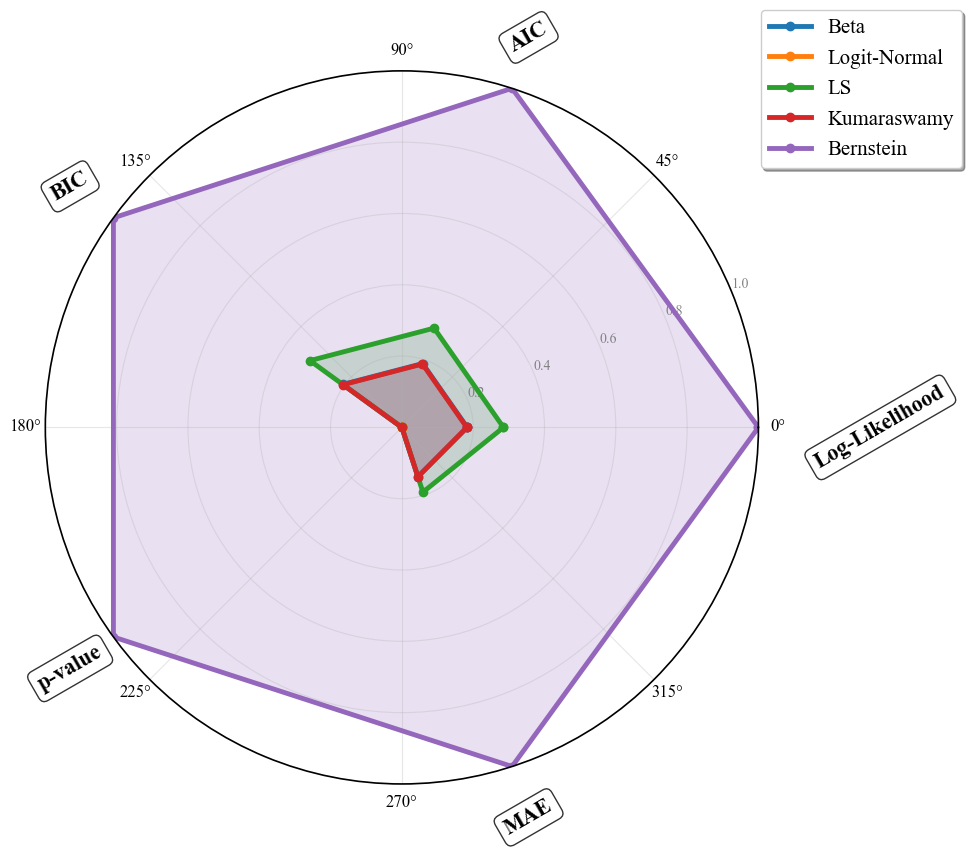

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 设置学术论文风格
def set_academic_style():
    """设置学术论文风格的绘图参数"""
    plt.style.use('default')
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
    rcParams['mathtext.fontset'] = 'stix'
    rcParams['font.size'] = 12
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 16
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    rcParams['figure.figsize'] = (10, 8)
    rcParams['figure.dpi'] = 100
    rcParams['savefig.dpi'] = 300
    rcParams['axes.linewidth'] = 1.2
    rcParams['lines.linewidth'] = 2
    rcParams['grid.linewidth'] = 0.8
    rcParams['grid.alpha'] = 0.25
    rcParams['axes.edgecolor'] = 'black'
    rcParams['axes.labelcolor'] = 'black'
    rcParams['xtick.color'] = 'black'
    rcParams['ytick.color'] = 'black'

# 绘制雷达图（简化版）
def plot_simple_radar():
    """绘制简化版模型比较雷达图"""
    set_academic_style()
    
    # 使用您提供的数据
    data = {
        'Model': ['Beta', 'LN', 'LS', 'KM', 'Bernstein'],
        'Prior': ['Beta', 'Logit-Normal', 'LS', 'Kumaraswamy', 'Bernstein'],
        'LogLikelihood': [-17019.60, -17122.88, -16962.41, -17020.34, -16559.76],
        'AIC': [34043.21, 34249.75, 33928.81, 34044.67, 33153.52],
        'BIC': [34056.24, 34262.79, 33941.85, 34057.71, 33255.80],
        'P.value': [0.0005, 0.0005, 0.0005, 0.0005, 0.1604],
        'MAE': [0.0113, 0.0129, 0.0108, 0.0113, 0.0019]
    }
    
    df = pd.DataFrame(data)
    
    # 选择要展示的指标
    metrics = ['LogLikelihood', 'AIC', 'BIC', 'P.value', 'MAE']
    N = len(metrics)
    
    # 标准化指标（使所有指标都是越高越好）
    df_normalized = df.copy()
    
    # 对AIC、BIC和MAE取负值（因为它们越低越好）
    df_normalized['AIC'] = -df_normalized['AIC']
    df_normalized['BIC'] = -df_normalized['BIC']
    df_normalized['MAE'] = -df_normalized['MAE']
    
    # 归一化到0-1范围
    for col in metrics:
        min_val = df_normalized[col].min()
        max_val = df_normalized[col].max()
        range_val = max_val - min_val
        if range_val > 0:
            df_normalized[col] = (df_normalized[col] - min_val) / range_val
        else:
            df_normalized[col] = 0.5  # 如果所有值相同，设为中间值
    
    # 创建极坐标图
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # 计算角度
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # 闭合多边形
    
    # 定义颜色
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Tableau调色板
    
    # 绘制每个模型的雷达图
    for i, model in enumerate(df_normalized['Model']):
        values = df_normalized[df_normalized['Model'] == model][metrics].values[0].tolist()
        values += values[:1]  # 闭合多边形
        
        ax.plot(angles, values, color=colors[i], linewidth=3.5, label=df_normalized['Prior'].iloc[i], marker = 'o', markersize = 6)
        ax.fill(angles, values, color=colors[i], alpha=0.2)
    
    # 设置角度和标签
    labels = [
        'Log-Likelihood', 
        'AIC', 
        'BIC', 
        'p-value', 
        'MAE'
    ]
    label_positions = angles[:-1]
    for label, angle in zip(labels, label_positions):
        # 根据角度调整标签的垂直对齐方式
        ha = 'center'
        if angle == 0:
            ha = "left"
        va = 'center'
        
        # 绘制标签，增加字体大小并调整位置
        ax.text(angle, 1.15, label, ha=ha, va=va, 
                fontsize=16, fontweight='bold', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8), 
                rotation = 30)
    
    # 设置网格和范围
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color='grey', size=10)
    ax.grid(True, alpha=0.3)
    
    # 添加图例
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), 
              frameon=True, fancybox=True, shadow=True, fontsize=15)
    
    # 添加标题
    # plt.title('Model Comparison Radar Chart', size=18, y=1.1, pad=30)
    
    # 添加说明文本
    # explanation = (
    #     "Note: AIC, BIC and MAE are inverted (higher values indicate better performance).\n"
    #     "All metrics are normalized to [0, 1] range for comparison."
    # )
    # plt.figtext(0.5, 0.01, explanation, ha='center', fontsize=10, style='italic')
    
    plt.tight_layout()
    return fig

# 生成雷达图
fig = plot_simple_radar()
plt.show()

# 保存图形（取消注释以保存）
# fig.savefig('model_comparison_radar.png', bbox_inches='tight', dpi=300, facecolor='white')

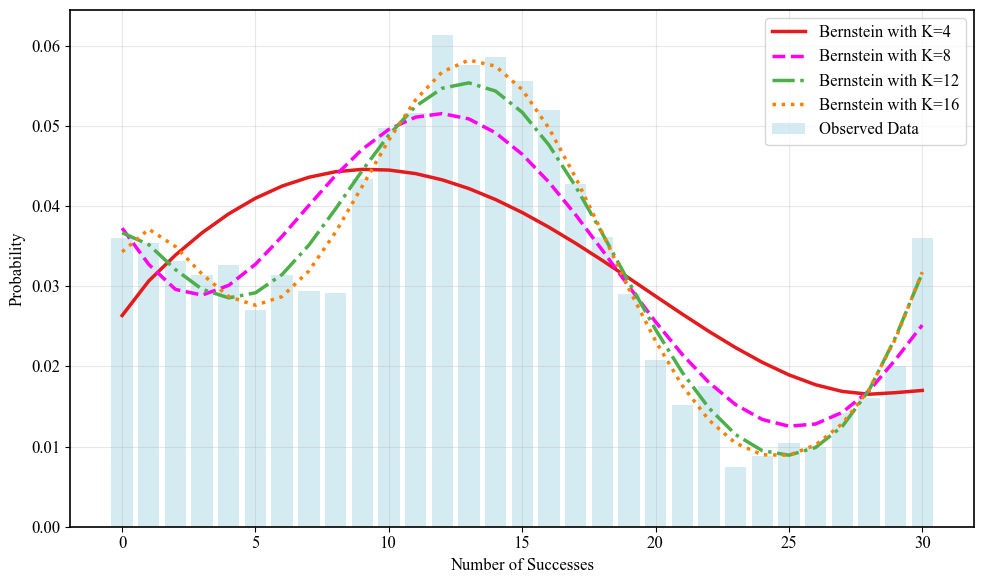

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
import seaborn as sns
from scipy.stats import binom, beta, norm
from scipy.special import expit, logit
import matplotlib.gridspec as gridspec

# 设置学术论文风格
def set_academic_style():
    """设置学术论文风格的绘图参数"""
    plt.style.use('default')
    rcParams['font.family'] = 'serif'
    rcParams['font.serif'] = ['Times New Roman']
    rcParams['mathtext.fontset'] = 'stix'
    rcParams['font.size'] = 12
    rcParams['axes.labelsize'] = 14
    rcParams['axes.titlesize'] = 16
    rcParams['xtick.labelsize'] = 12
    rcParams['ytick.labelsize'] = 12
    rcParams['legend.fontsize'] = 12
    rcParams['figure.figsize'] = (10, 6)
    rcParams['figure.dpi'] = 100
    rcParams['savefig.dpi'] = 300
    rcParams['axes.linewidth'] = 1.2
    rcParams['lines.linewidth'] = 2
    rcParams['grid.linewidth'] = 0.8
    rcParams['grid.alpha'] = 0.25

# 设置样式
set_academic_style()

# 读取数据
sample_data = pd.read_csv(r'C:\Users\user\Desktop\Accurate prior of binomial distribution with Bernstein polynomial and its Bayesian inference\sample.csv')
x = sample_data['x'].values
n_trials = 30  # 二项分布试验次数
sample_size = len(x)  # 使用实际样本大小

# 2. 模型拟合结果
models = ['Bernstein4', 'Bernstein8', 'Bernstein12', 'Bernstein16']
# 模型参数
model_params = {
    'Bernstein4': np.array([1.425727e-01, 3.615512e-01, 3.772077e-01, 1.861233e-06, 1.186665e-01]),
    'Bernstein8': np.array([1.637388e-01, 7.458270e-06, 5.240492e-05, 4.980296e-01, 2.254033e-01, 3.937626e-09, 6.099886e-20, 5.252724e-22, 1.127684e-01]),
    'Bernstein12': np.array([9.107427e-02, 1.165545e-01, 3.959352e-06, 4.473055e-07, 4.317039e-04, 4.778463e-01, 
                             2.051634e-01, 9.295968e-06, 1.364357e-11, 5.533507e-15, 1.382270e-13, 6.224362e-09, 1.089161e-01]),
    'Bernstein16': np.array([4.397067e-02, 1.399036e-01, 3.331913e-02, 6.291738e-04, 1.113746e-04, 9.623777e-04,
                             4.748693e-02, 4.794812e-01, 1.342065e-01, 1.551046e-03, 8.876687e-06, 6.489614e-07,
                             4.562082e-06, 8.767626e-04, 2.813403e-02, 1.555434e-03, 8.779766e-02])
}

# 定义伯恩斯坦先验的概率密度函数
def bernstein_prior(p, weights):
    """计算伯恩斯坦先验的概率密度函数"""
    K = len(weights) - 1
    result = np.zeros_like(p)
    for k in range(K + 1):
        result += weights[k] * beta.pdf(p, k + 1, K - k + 1)
    return result

# 计算二项分布的概率质量函数（考虑先验）
def binomial_with_prior_pmf(k, n, prior_func, prior_weights):
    """计算考虑先验的二项分布概率质量函数"""
    # 数值积分计算边缘分布
    p_values = np.linspace(0.001, 0.999, 1000)
    prior_probs = prior_func(p_values, prior_weights)
    
    # 归一化先验概率
    prior_probs /= np.trapz(prior_probs, p_values)
    
    # 计算每个k值的概率
    pmf = np.zeros_like(k, dtype=float)
    for i, k_val in enumerate(k):
        # 二项分布概率
        binom_probs = binom.pmf(k_val, n, p_values)
        # 边缘概率
        pmf[i] = np.trapz(binom_probs * prior_probs, p_values)
    
    return pmf

# 1. 拟合优度对比图
def plot_fit_comparison():
    """绘制拟合优度对比图"""
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    
    # 计算观测数据的直方图
    k_values = np.arange(0, n_trials + 1)
    observed_freq, _ = np.histogram(x, bins=np.arange(-0.5, n_trials + 1.5))
    observed_prob = observed_freq / len(x)
    
    # 绘制观测数据
    ax1.bar(k_values, observed_prob, alpha=0.5, color="lightblue", label='Observed Data')
    
    # 定义颜色和线型
    colors = ['#E41A1C', "#FF00F2", '#4DAF4A', '#FF7F00']
    linestyles = ['-', '--', '-.', ':']
    
    # 绘制各模型的拟合曲线
    for i, model in enumerate(models):
        # 计算模型预测的概率
        weights = model_params[model]
        model_pmf = binomial_with_prior_pmf(k_values, n_trials, bernstein_prior, weights)
        
        # 绘制模型拟合曲线
        ax1.plot(k_values, model_pmf, color=colors[i], linestyle=linestyles[i], 
                linewidth=2.5, label=f'Bernstein with K={len(weights)-1}')
    
    # 设置第一个子图
    ax1.set_xlabel('Number of Successes')
    ax1.set_ylabel('Probability')
    # ax1.set_title('Bernstein-Binomial Convergence')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# 生成所有图形
fig1 = plot_fit_comparison()

# 显示图形
plt.show()